### **6.7 Full Data Preprocessing Project**

**Dataset:** Loan Approval Dataset - `loan.csv`

This notebook demonstrates a complete data preprocessing pipeline for a loan approval dataset, including:
- Loading and cleaning data
- Handling missing values
- Outlier treatment
- Encoding categorical features
- Handling imbalanced data
- Feature scaling

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', "{:.3f}".format)

### 2. Data Loading & basic cleanup

In [3]:
df = pd.read_csv("loan.csv")
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns.tolist())
df.head()

Shape of the dataset: (614, 13)
Columns in the dataset: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


In [4]:
# convert column names to lowercase
df.columns = [col.lower() for col in df.columns]

In [5]:
# basic cleanup
# drop id line columns
df = df.drop(columns=["loan_id"]) 

In [7]:
target_col = "loan_status"

In [8]:
# Convert Y, N to 1, 0
df[target_col] = df[target_col].map({"Y": 1, "N": 0})

In [9]:
df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,1
4,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,1


### 3. Train Test Spit

In [10]:
# separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (491, 11)
Test shape : (123, 11)


In [13]:
# creating copies to avoid modifying original data
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

### 4. Identify numerical and categorical columns

| Column | Column Type | Feature Type | Preprocessing Action |
|------|------------|-------------|----------------------|
| gender | Categorical | Nominal | One Hot Encoding |
| married | Categorical | Nominal | One Hot Encoding |
| dependents | Categorical | Ordinal | Ordinal Encoding |
| education | Categorical | Nominal | One Hot Encoding |
| self_employed | Categorical | Nominal | One Hot Encoding |
| property_area | Categorical | Nominal | One Hot Encoding |
| applicantincome | Numerical | Continuous | Scaling |
| coapplicantincome | Numerical | Continuous | Scaling |
| loanamount | Numerical | Continuous | Scaling |
| loan_amount_term | Numerical | Discrete | Scaling |
| credit_history | Numerical | Binary | Keep as is |
| loan_status | Categorical | Binary (Target) | No encoding |

In [14]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             480 non-null    str    
 1   married            488 non-null    str    
 2   dependents         483 non-null    str    
 3   education          491 non-null    str    
 4   self_employed      464 non-null    str    
 5   applicantincome    491 non-null    int64  
 6   coapplicantincome  491 non-null    float64
 7   loanamount         471 non-null    float64
 8   loan_amount_term   479 non-null    float64
 9   credit_history     448 non-null    float64
 10  property_area      491 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 46.0 KB


In [15]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# always validate manually as sometimes datatypes are not inferred correctly and encoded already

Numerical columns: ['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']
Categorical columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'property_area']


/var/folders/zp/zh_rycfs4j14qq7_xth9cy8h0000gn/T/ipykernel_43960/1149710012.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


### 5. Handling Missing Values

In [16]:
# numerical columns - median 
if num_cols:
    num_imputer = SimpleImputer(strategy="median")
    # fit & transform on training data, transform on test data
    X_train_processed[num_cols] = num_imputer.fit_transform(X_train_processed[num_cols])
    X_test_processed[num_cols] = num_imputer.transform(X_test_processed[num_cols])

# categorical columns - most frequent
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    # fit & transform on training data, transform on test data
    X_train_processed[cat_cols] = cat_imputer.fit_transform(X_train_processed[cat_cols])
    X_test_processed[cat_cols] = cat_imputer.transform(X_test_processed[cat_cols])

print("Missing values in training set:", X_train_processed.isnull().sum())
print("Missing values in test set:", X_test_processed.isnull().sum())

Missing values in training set: gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64
Missing values in test set: gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64


### 6. Outlier Treatment

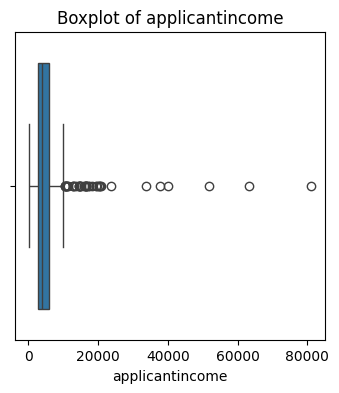

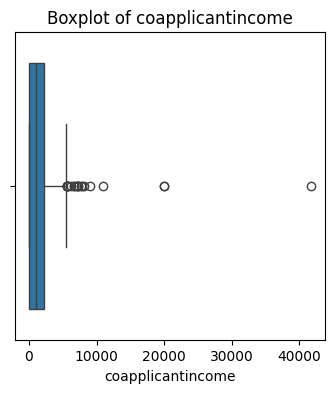

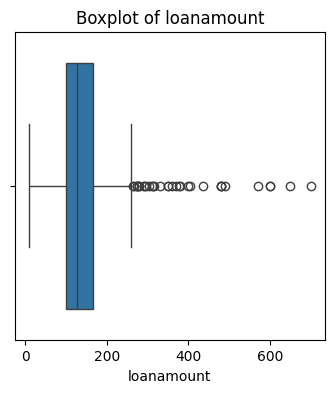

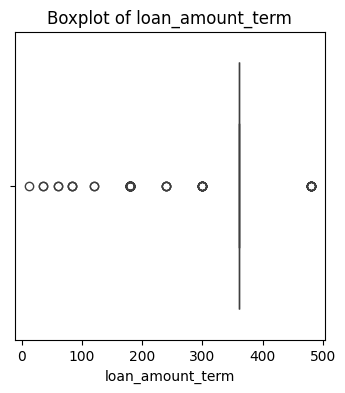

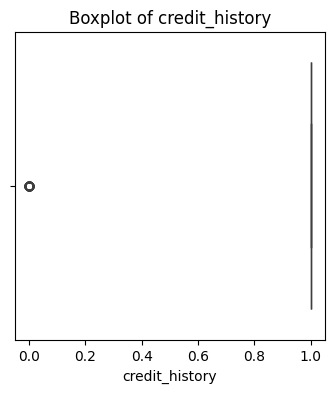

In [17]:
for col in num_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x=X_train_processed[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Outlier Treatment Decision (Loan Dataset)**

**Numerical Columns**
- applicantincome
- coapplicantincome
- loanamount
- loan_amount_term
- credit_history

---

**Outlier Capping Decisions**

| Column | Cap Outliers? | Reason |
|------|--------------|--------|
| applicantincome | Yes | Continuous feature with strong right skew and extreme values |
| coapplicantincome | Yes | Many zeros and few very large values causing skew |
| loanamount | Yes | Large loan values can dominate model learning |
| loan_amount_term | No | Discrete, domain-valid values like 120, 180, 240, 360 |
| credit_history | No | Binary feature (0 or 1), outliers do not exist |

---

**Final Rule of Thumb**

- Apply outlier treatment **only** to continuous numerical features.
- Do **not** cap discrete or binary numerical columns.
- Always handle missing values before outlier treatment.

> Outlier capping is required only where extreme values distort the data distribution.

In [18]:
# Outlier treatment - IQR capping
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

def compute_train_bounds(df, cols):
    bounds = {}
    for col in cols:
        low, high = iqr_bounds(df[col])
        bounds[col] = (low, high)
    return bounds

def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    for col, (low, high) in bounds.items():
        df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > high, high, df_capped[col])
    return df_capped

In [19]:
X_train_processed.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='str')

In [20]:
outlier_cols = ["applicantincome", "coapplicantincome", "loanamount"]

train_bounds = compute_train_bounds(X_train_processed, outlier_cols)

In [21]:
train_bounds


{'applicantincome': (np.float64(-1472.5), np.float64(10203.5)),
 'coapplicantincome': (np.float64(-3361.5), np.float64(5602.5)),
 'loanamount': (np.float64(3.75), np.float64(261.75))}

In [22]:
X_train_processed[outlier_cols] = cap_outliers_with_bounds(X_train_processed[outlier_cols], train_bounds)
X_test_processed[outlier_cols] = cap_outliers_with_bounds(X_test_processed[outlier_cols], train_bounds)

### 7. Encoding Categorical columns

**LabelEncoding**

In [23]:
for col in cat_cols:
    print(col, X_train_processed[col].unique())
    print("-"*20)

gender <StringArray>
['Male', 'Female']
Length: 2, dtype: str
--------------------
married <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------
dependents <StringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str
--------------------
education <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
--------------------
self_employed <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------
property_area <StringArray>
['Urban', 'Semiurban', 'Rural']
Length: 3, dtype: str
--------------------


**NOTE: here, only one column is multi-class nominal - property_area (needs one-hot-encoding); others are binary / ordinal. so, let's use only label encoding for simplicity. Based on model performance, we can try one hot encoding**

In [24]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    label_encoders[col] = le

    X_train_processed[col] = le.transform(X_train_processed[col])
    X_test_processed[col] = le.transform(X_test_processed[col])

In [25]:
print(label_encoders)

{'gender': LabelEncoder(), 'married': LabelEncoder(), 'dependents': LabelEncoder(), 'education': LabelEncoder(), 'self_employed': LabelEncoder(), 'property_area': LabelEncoder()}


**NOTE: OrdinalEncoder can also be used**

In [26]:
X_train_processed[cat_cols].head()

,gender,married,dependents,education,self_employed,property_area
154,1,0,0,0,0,2
239,1,1,1,0,0,1
448,1,1,2,0,0,0
471,1,1,1,1,0,0
273,1,1,0,0,0,1


### 8. Handle imbalanced data

In [27]:
# check target column distribution
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("-"*50)

print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

loan_status
1    337
0    154
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


In [28]:
smote = SMOTE(random_state=42)

In [29]:
# should be balanced only on training set
X_train_processed, y_train_processed = smote.fit_resample(X_train_processed, y_train)

In [30]:
# check target column distribution
print(y_train_processed.value_counts())
print(y_train_processed.value_counts(normalize=True))

print("-"*50)

print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

loan_status
1    337
0    337
Name: count, dtype: int64
loan_status
1   0.500
0   0.500
Name: proportion, dtype: float64
--------------------------------------------------
loan_status
1    85
0    38
Name: count, dtype: int64
loan_status
1   0.686
0   0.314
Name: proportion, dtype: float64


### 9. Standardization - Standard Scaler

In [31]:
#  Scaling - Standardization
scaler = StandardScaler()

In [32]:
# columns to scale
scale_cols = ["applicantincome", "coapplicantincome", "loanamount", "loan_amount_term"]

In [33]:
scaler.fit(X_train_processed[scale_cols])

# fit_transform on training data, transform on test data
X_train_processed[scale_cols] = scaler.transform(X_train_processed[scale_cols])
X_test_processed[scale_cols] = scaler.transform(X_test_processed[scale_cols])

In [34]:
X_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,-0.607,-0.853,-1.642,0.270,1.000,2
1,1,1,1,0,0,-0.582,-0.853,-0.799,0.270,1.000,1
2,1,1,2,0,0,-0.572,0.216,0.191,0.270,0.000,0
3,1,1,1,1,0,-0.855,0.084,-0.487,-2.653,0.000,0
4,1,1,0,0,0,-0.868,0.536,0.191,0.270,1.000,1


In [35]:
print("\nFinal shapes:")
print("X_train_processed:", X_train_processed.shape)
print("y_train_processed:", y_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)
print("y_test       :", y_test.shape)


Final shapes:
X_train_processed: (674, 11)
y_train_processed: (674,)
X_test_processed : (123, 11)
y_test       : (123,)


---

**End of preprocessing pipeline.**

You can now use `X_train_processed`, `y_train_processed`, `X_test_processed`, and `y_test` for model training and evaluation.